# Estudo Dirigido – Parte 2
## Atividades 4 e 5 – Convolução Discreta e Suavização de Sinais

---

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

/home/luiza/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## Atividade 4 – Implementação Computacional da Convolução

### Dados do problema

$$x[n] = \{1,\ 2,\ 1\} \qquad h[n] = \{1,\ 1\}$$

A convolução discreta é definida por:

$$y[n] = x[n] * h[n] = \sum_{k=-\infty}^{+\infty} x[k]\, h[n-k]$$

O comprimento da saída será $L = \text{len}(x) + \text{len}(h) - 1 = 3 + 2 - 1 = 4$ amostras.

In [4]:
x = np.array([1, 2, 1])
h = np.array([1, 1])
y = np.convolve(x, h)

print('Sequência x[n]:', x)
print('Sequência h[n]:', h)
print('Convolução y[n] = x[n] * h[n]:', y)

Sequência x[n]: [1 2 1]
Sequência h[n]: [1 1]
Convolução y[n] = x[n] * h[n]: [1 3 3 1]


### Comparação com o cálculo manual

| n | Cálculo manual | `np.convolve` | Coincide? |
|---|:-:|:-:|:-:|
| 0 | 1 | 1 | Sim |
| 1 | 3 | 3 | Sim |
| 2 | 3 | 3 | Sim |
| 3 | 1 | 1 | Sim |

Os resultados coincidem perfeitamente com o cálculo analítico.

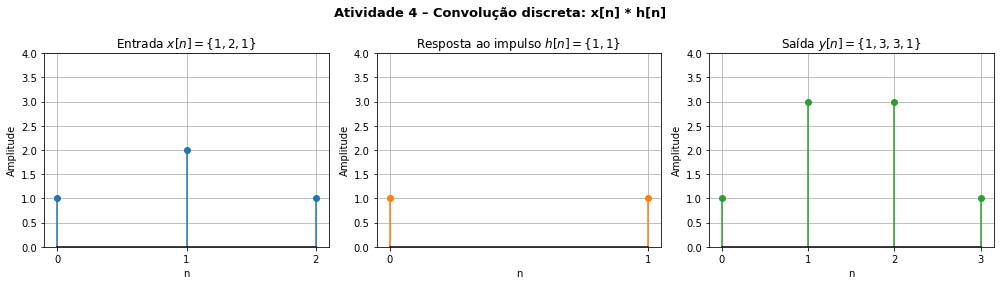

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].stem(range(len(x)), x, basefmt='k-')
axes[0].set_title('Entrada $x[n] = \{1, 2, 1\}$')
axes[0].set_xlabel('n'); axes[0].set_ylabel('Amplitude')
axes[0].set_xticks(range(len(x))); axes[0].set_ylim(0, 4)

axes[1].stem(range(len(h)), h, linefmt='C1-', markerfmt='C1o', basefmt='k-')
axes[1].set_title('Resposta ao impulso $h[n] = \{1, 1\}$')
axes[1].set_xlabel('n'); axes[1].set_ylabel('Amplitude')
axes[1].set_xticks(range(len(h))); axes[1].set_ylim(0, 4)

axes[2].stem(range(len(y)), y, linefmt='C2-', markerfmt='C2o', basefmt='k-')
axes[2].set_title('Saída $y[n] = \{1, 3, 3, 1\}$')
axes[2].set_xlabel('n'); axes[2].set_ylabel('Amplitude')
axes[2].set_xticks(range(len(y))); axes[2].set_ylim(0, 4)

plt.suptitle('Atividade 4 – Convolução discreta: x[n] * h[n]', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação do resultado

O filtro $h[n] = \{1, 1\}$ realiza a operação $y[n] = x[n] + x[n-1]$, somando cada amostra com a anterior.

- A saída tem **4 amostras** — sempre $\text{len}(x) + \text{len}(h) - 1$, pois a convolução alarga o sinal no tempo.
- O formato $\{1, 3, 3, 1\}$ é **simétrico** pois a entrada $\{1, 2, 1\}$ também o é.
- Os máximos ($y[1] = y[2] = 3$) ocorrem onde há maior sobreposição entre $x[n]$ e $h[n]$.
- Os extremos ($y[0] = y[3] = 1$) são as bordas onde apenas uma amostra contribui.

### Modificação da entrada: $x[n] = \{1, 1, 1, 1\}$

Entrada modificada x[n]: [1 1 1 1]
Saída y[n]: [1 2 2 2 1]


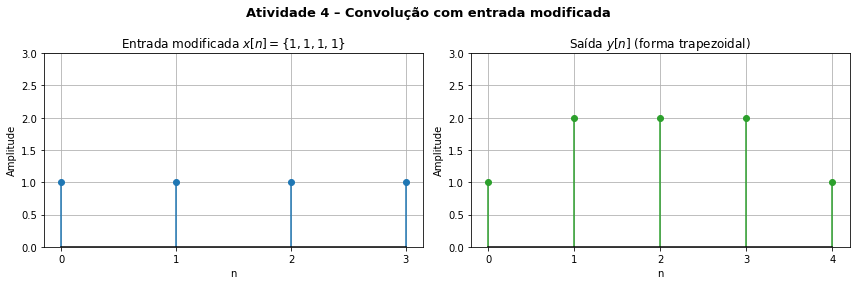

In [6]:
x_mod = np.array([1, 1, 1, 1])
y_mod = np.convolve(x_mod, h)

print('Entrada modificada x[n]:', x_mod)
print('Saída y[n]:', y_mod)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stem(range(len(x_mod)), x_mod, basefmt='k-')
axes[0].set_title('Entrada modificada $x[n] = \{1, 1, 1, 1\}$')
axes[0].set_xlabel('n'); axes[0].set_ylabel('Amplitude')
axes[0].set_xticks(range(len(x_mod))); axes[0].set_ylim(0, 3)

axes[1].stem(range(len(y_mod)), y_mod, linefmt='C2-', markerfmt='C2o', basefmt='k-')
axes[1].set_title(f'Saída $y[n]$ (forma trapezoidal)')
axes[1].set_xlabel('n'); axes[1].set_ylabel('Amplitude')
axes[1].set_xticks(range(len(y_mod))); axes[1].set_ylim(0, 3)

plt.suptitle('Atividade 4 – Convolução com entrada modificada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação da entrada modificada

Com $x[n] = \{1,1,1,1\}$, a saída $y[n] = \{1, 2, 2, 2, 1\}$ tem **formato trapezoidal**:

- As bordas $\{1\}$ são o **transitório**: apenas uma amostra cabe na janela do filtro.
- A região central $\{2, 2, 2\}$ é o **regime permanente**: duas amostras unitárias sempre somam 2.
- Isso ilustra a diferença entre resposta transitória e regime permanente de forma direta.

---
## Atividade 5 – Suavização de Sinais

### Dados do problema

Sinal de sensor:
$$x[n] = \{2,\ 5,\ 4,\ 6,\ 8,\ 7,\ 5,\ 4\}$$

Filtro de média simples de 3 pontos:
$$h[n] = \frac{1}{3}\{1,\ 1,\ 1\}$$

Em cada instante $n$, a saída é a média de três amostras consecutivas:
$$y[n] = \frac{x[n] + x[n-1] + x[n-2]}{3}$$

In [7]:
x5 = np.array([2, 5, 4, 6, 8, 7, 5, 4])
h5 = np.array([1/3, 1/3, 1/3])
y5 = np.convolve(x5, h5)

print('Sinal original  x[n]:', x5)
print('Sinal filtrado  y[n]:', np.round(y5, 3))
print(f'Comprimento original: {len(x5)} | Comprimento filtrado: {len(y5)}')

Sinal original  x[n]: [2 5 4 6 8 7 5 4]
Sinal filtrado  y[n]: [0.667 2.333 3.667 5.    6.    7.    6.667 5.333 3.    1.333]
Comprimento original: 8 | Comprimento filtrado: 10


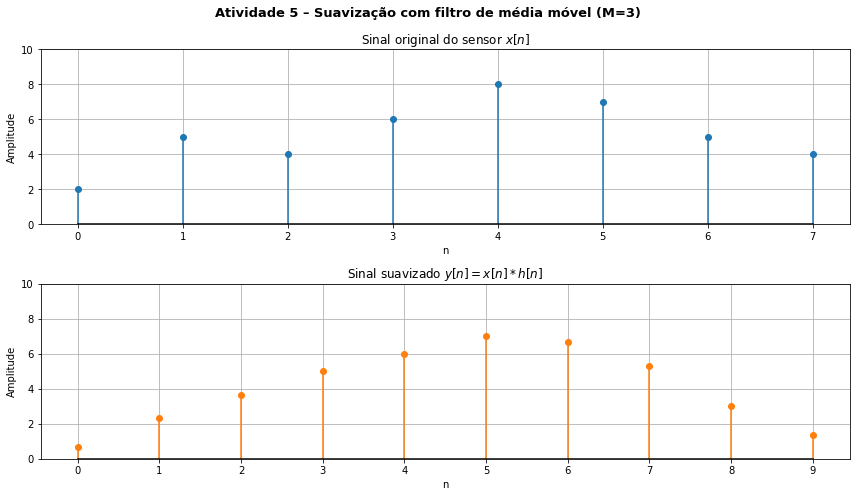

In [8]:
nx = np.arange(len(x5))
ny = np.arange(len(y5))

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].stem(nx, x5, basefmt='k-')
axes[0].set_title('Sinal original do sensor $x[n]$')
axes[0].set_xlabel('n'); axes[0].set_ylabel('Amplitude')
axes[0].set_xticks(nx); axes[0].set_ylim(0, 10)

axes[1].stem(ny, np.round(y5, 3), linefmt='C1-', markerfmt='C1o', basefmt='k-')
axes[1].set_title('Sinal suavizado $y[n] = x[n] * h[n]$')
axes[1].set_xlabel('n'); axes[1].set_ylabel('Amplitude')
axes[1].set_xticks(ny); axes[1].set_ylim(0, 10)

plt.suptitle('Atividade 5 – Suavização com filtro de média móvel (M=3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

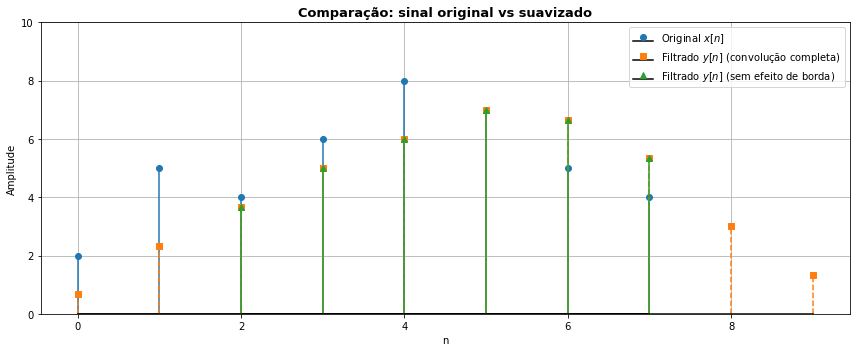

In [9]:
# Comparação: original vs filtrado (com e sem efeito de borda)
y5_valido = y5[2:len(x5)]
nx_valido = np.arange(2, 2 + len(y5_valido))

fig, ax = plt.subplots(figsize=(12, 5))

m1, s1, b1 = ax.stem(nx, x5, basefmt='k-', label='Original $x[n]$')
plt.setp(s1, color='C0'); plt.setp(m1, color='C0')

m2, s2, b2 = ax.stem(ny, np.round(y5,3), basefmt='k-', label='Filtrado $y[n]$ (convolução completa)')
plt.setp(s2, color='C1', linestyle='--'); plt.setp(m2, color='C1', marker='s')

m3, s3, b3 = ax.stem(nx_valido, np.round(y5_valido,3), basefmt='k-', label='Filtrado $y[n]$ (sem efeito de borda)')
plt.setp(s3, color='C2'); plt.setp(m3, color='C2', marker='^')

ax.set_title('Comparação: sinal original vs suavizado', fontsize=13, fontweight='bold')
ax.set_xlabel('n'); ax.set_ylabel('Amplitude')
ax.set_ylim(0, 10); ax.legend()
plt.tight_layout()
plt.show()

### Por que esse filtro atua como suavizador?

O filtro de média móvel $h[n] = \frac{1}{3}\{1,1,1\}$ suaviza o sinal por três razões complementares:

**1. Média das amostras vizinhas**  
Em cada instante, $y[n]$ é a média aritmética de três amostras consecutivas. Um pico isolado tem seu efeito reduzido a $1/3$ na saída, pois as amostras vizinhas compensam.

**2. Filtro passa-baixas**  
O filtro atenua componentes de alta frequência (variações rápidas, ruídos) e preserva as de baixa frequência (tendência geral do sinal). Para ruído branco de variância $\sigma^2$, a variância na saída cai para $\sigma^2/M$.

**3. Memória de M amostras**  
O filtro distribui um pico ao longo de 3 amostras em vez de deixá-lo concentrado.

### Limitações

| Limitação | Descrição |
|---|---|
| **Efeito de borda** | Primeiras e últimas $M-1$ amostras são distorcidas (janela incompleta) |
| **Atraso** | Introduz atraso de $(M-1)/2$ amostras — problemático em controle em tempo real |
| **Perda de detalhes** | Eventos rápidos legítimos também são atenuados junto com o ruído |
| **Resposta não ideal** | Lóbulos laterais significativos — filtros com janela Hamming/Kaiser são superiores |